In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from OceanDataStore import OceanDataCatalog
from region import Region


import xarray as xr
import matplotlib.pyplot as plt
from glob import glob

In [3]:
# load SOSE transect
fsose = '../data/SOSE/Adelie_138E_150E/Adelie*.nc'
sose = xr.open_mfdataset(glob(fsose))

# load SLA
sla = SLA(deg=0.25).da

# use SOSE data to define time and loc bounds
extent = [sose.XC.min(), sose.XC.max(), sose.YC.min(), sose.YC.max()]

# CROP SLA
sla = Region('AC',extent).crop_da(sla)
# convert to m
sla = sla / 100

# define time bounds covering both datasets
t1 = sose.time[0]
t2 = sla.time[-1]

# take new anomaly
sla = sla - sla.sel(time=slice(t1,t2)).mean('time')

# take anomaly of SOSE later - after its been adjusted for the sea ice
#sose_etan = sose.ETAN - sose.ETAN.sel(time=slice(t1,t2)).mean('time')

In [ ]:
#sose_etan.load()

<xarray.DataArray 'ETAN' (time: 803, YC: 15, XC: 72)> Size: 3MB
array([[[-0.460577  , -0.4608724 , -0.45991278, ..., -0.12915313,
         -0.12135601, -0.11059952],
        [-0.44597888, -0.44527626, -0.44363642, ..., -0.12470043,
         -0.1179415 , -0.1079179 ],
        [-0.4309671 , -0.4290495 , -0.42644286, ..., -0.11492682,
         -0.10870659, -0.10052764],
        ...,
        [-0.2799213 , -0.2753203 , -0.2726512 , ...,  0.11039746,
          0.09405327,  0.08092177],
        [-0.23492432, -0.23218668, -0.23214161, ...,  0.1322689 ,
          0.11211801,  0.09652483],
        [-0.1824193 , -0.18129706, -0.18330157, ...,  0.1515826 ,
          0.12692523,  0.11207151]],

       [[-0.50620556, -0.49915934, -0.49186182, ..., -0.25295925,
         -0.24899173, -0.24508798],
        [-0.48638296, -0.4791267 , -0.47159457, ..., -0.2518015 ,
         -0.2481879 , -0.24532998],
        [-0.46615672, -0.45917177, -0.45224953, ..., -0.24433959,
         -0.24049747, -0.23912072],
...
        [ 0.17377543,  0.15828907,  0.19088507, ...,  0.0731231 ,
          0.09487331,  0.1194607 ],
        [ 0.13518262,  0.1378268 ,  0.16127503, ...,  0.05226004,
          0.06591213,  0.08610725],
        [ 0.09846008,  0.09756851,  0.11792362, ...,  0.06432545,
          0.06632423,  0.0729382 ]],

       [[ 0.15755105,  0.15963984,  0.15655756, ...,  0.18770778,
          0.2066884 ,  0.22070384],
        [ 0.16767526,  0.1611247 ,  0.15557647, ...,  0.19954324,
          0.21331728,  0.2256378 ],
        [ 0.14174342,  0.13584328,  0.13489974, ...,  0.20487475,
          0.21658397,  0.22748232],
        ...,
        [ 0.12914681,  0.16744947,  0.18922603, ...,  0.13206232,
          0.13730276,  0.14164257],
        [ 0.1432327 ,  0.17221212,  0.18297791, ...,  0.11669111,
          0.11775517,  0.11962497],
        [ 0.13061523,  0.14760768,  0.16154063, ...,  0.10912478,
          0.11073232,  0.1084342 ]]], shape=(803, 15, 72), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2013-01-03T12:00:00 ... 2023-12-27T12:...
    iter     (time) int64 6kB 360 720 1080 1440 ... 288000 288360 288720 289080
  * YC       (YC) float64 120B -65.97 -65.91 -65.84 ... -65.15 -65.08 -65.01
  * XC       (XC) float64 576B 138.1 138.2 138.4 138.6 ... 149.6 149.8 149.9
    rA       (YC, XC) float64 9kB 5.692e+07 5.692e+07 ... 6.13e+07 6.13e+07
    Depth    (YC, XC) float64 9kB 900.0 950.0 950.0 ... 3.32e+03 3.32e+03
Attributes:
    standard_name:  ETAN
    long_name:      Surface Height Anomaly
    units:          m

In [4]:
# load nemo data
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
nemo = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d',variable_names=['zos'])

# prepare nemo
# crop to region
lats = nemo.nav_lat.load()
lons = nemo.nav_lon.load()
mask = (lats >= extent[2]) & (lats <= extent[3]) & (lons >= extent[0]) & (lons <= extent[1])
# crop to time
zos = nemo.zos.where(mask,drop=True)
# make monthly
zos = zos.resample({'time_counter':'MS'}).mean()
# relative anomaly wrt common time period
zos = zos - zos.sel(time_counter=slice(t1,t2)).mean('time_counter')

  2026-03-16T11:09:31.136093Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



In [5]:
zos.load()

<xarray.DataArray 'zos' (time_counter: 594, y: 28, x: 142)> Size: 9MB
array([[[-1.30617619e-03, -3.84807587e-04,  7.20024109e-04, ...,
          2.49568224e-02,  2.45563984e-02,  2.41961479e-02],
        [-3.91006470e-04,  4.37736511e-04,  1.43337250e-03, ...,
          2.48590708e-02,  2.45083570e-02,  2.41997242e-02],
        [ 5.67674637e-04,  1.27160549e-03,  2.13396549e-03, ...,
          2.44156122e-02,  2.41643190e-02,  2.39410400e-02],
        ...,
        [-3.22461128e-04, -4.50253487e-04, -6.21080399e-04, ...,
          1.91605091e-03,  1.77979469e-03,  1.89495087e-03],
        [-9.84668732e-04, -1.15168095e-03, -1.38223171e-03, ...,
          2.57611275e-04, -4.29153442e-05, -1.53422356e-04],
        [-1.63888931e-03, -1.82282925e-03, -2.08389759e-03, ...,
         -2.03168392e-03, -2.49683857e-03, -2.83360481e-03]],

       [[-1.40957832e-02, -1.33540630e-02, -1.25511885e-02, ...,
          6.32774830e-03,  6.02149963e-03,  5.72133064e-03],
        [-1.32719278e-02, -1.25455856e-02, -1.18013620e-02, ...,
          6.77096844e-03,  6.56461716e-03,  6.35468960e-03],
        [-1.22946501e-02, -1.16035938e-02, -1.09580755e-02, ...,
          6.81555271e-03,  6.73770905e-03,  6.64532185e-03],
...
         -9.35702324e-02, -8.92508030e-02, -8.49273205e-02],
        [-1.08696222e-02, -9.96029377e-03, -9.01508331e-03, ...,
         -9.55226421e-02, -9.08346176e-02, -8.62245560e-02],
        [-1.28407478e-02, -1.17602348e-02, -1.06207132e-02, ...,
         -9.53515768e-02, -9.03804302e-02, -8.55736732e-02]],

       [[ 1.36471987e-02,  1.42095089e-02,  1.50142908e-02, ...,
         -4.20582294e-03, -4.04155254e-03, -3.86881828e-03],
        [ 1.36212111e-02,  1.39921904e-02,  1.46014690e-02, ...,
         -4.67419624e-03, -4.43649292e-03, -4.20498848e-03],
        [ 1.35270357e-02,  1.37377977e-02,  1.41744614e-02, ...,
         -5.45310974e-03, -5.14686108e-03, -4.86123562e-03],
        ...,
        [ 3.77714634e-03,  4.43756580e-03,  5.36060333e-03, ...,
         -7.77428150e-02, -7.49369860e-02, -7.18184710e-02],
        [ 1.61552429e-03,  2.38978863e-03,  3.46922874e-03, ...,
         -8.15525055e-02, -7.85421133e-02, -7.52121210e-02],
        [-7.00354576e-04,  1.45912170e-04,  1.34158134e-03, ...,
         -8.41115713e-02, -8.09552670e-02, -7.74552822e-02]]],
      shape=(594, 28, 142), dtype=float32)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 5kB 1976-01-01 ... 2025-06-01
  * y             (y) int64 224B 978 979 980 981 982 ... 1002 1003 1004 1005
  * x             (x) int64 1kB 782 783 784 785 786 787 ... 919 920 921 922 923
    nav_lat       (y, x) float64 32kB -65.94 -65.94 -65.94 ... -65.01 -65.01
    nav_lon       (y, x) float64 32kB 138.2 138.2 138.3 ... 149.7 149.8 149.9
Attributes:
    standard_name:       sea_surface_height_above_geoid
    long_name:           Sea Surface Height Above Geoid
    units:               m
    online_operation:    average
    interval_operation:  450 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 450 s)

In [6]:
rho_w = 1028.5
rho_ice = 910
rho_snow = 330

sload = (sose.SIheff * rho_ice) + (sose.SIhsnow * rho_snow)

sload = sload / rho_w

# correct SSH for loading
etan = (sose.ETAN + sload)

# compute SOSE ssh anomaly wrt to same mean as SLA
etan = etan - etan.sel(time=slice(t1,t2)).mean('time')
etan = etan.resample({'time':'MS'}).mean()


In [7]:
etan.load()

<xarray.DataArray (time: 132, YC: 15, XC: 72)> Size: 570kB
array([[[-0.15731955, -0.15415138, -0.15133518, ..., -0.13604183,
         -0.13822474, -0.13951117],
        [-0.149328  , -0.14674266, -0.14452405, ..., -0.12678327,
         -0.12980811, -0.1319962 ],
        [-0.14129655, -0.13937776, -0.13783173, ..., -0.11375549,
         -0.11720685, -0.1203958 ],
        ...,
        [-0.05635683, -0.05214665, -0.05099607, ...,  0.04060036,
          0.03891116,  0.03438747],
        [-0.03925385, -0.0355463 , -0.03507559, ...,  0.05653743,
          0.05440682,  0.04941962],
        [-0.02760581, -0.02465671, -0.02496549, ...,  0.07221534,
          0.06998754,  0.06483921]],

       [[-0.15436089, -0.15166193, -0.15029663, ..., -0.13959734,
         -0.14238144, -0.14435023],
        [-0.14883234, -0.14653851, -0.14549567, ..., -0.12597604,
         -0.12920187, -0.13175398],
        [-0.14436837, -0.1428078 , -0.14208813, ..., -0.11054248,
         -0.11388594, -0.11689427],
...
        [ 0.06070358,  0.06110305,  0.05896002, ...,  0.02821265,
          0.02859273,  0.02936584],
        [ 0.05777055,  0.05684878,  0.05389698, ...,  0.03093843,
          0.02914906,  0.02800719],
        [ 0.05075065,  0.05027282,  0.04808901, ...,  0.03862949,
          0.03490816,  0.03088993]],

       [[ 0.07171825,  0.07369002,  0.07665926, ...,  0.04305265,
          0.04348449,  0.04458426],
        [ 0.0721282 ,  0.07349527,  0.07576843, ...,  0.04062043,
          0.04097714,  0.04207544],
        [ 0.07009077,  0.07102901,  0.07289823, ...,  0.03858125,
          0.0389865 ,  0.04015841],
        ...,
        [ 0.06218133,  0.0634562 ,  0.06812004, ...,  0.03555278,
          0.03223139,  0.03099597],
        [ 0.06009235,  0.06168242,  0.06540135, ...,  0.03802403,
          0.03291905,  0.02958626],
        [ 0.05633875,  0.05712454,  0.05927346, ...,  0.04374244,
          0.0372266 ,  0.03087389]]], shape=(132, 15, 72), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2013-01-01 2013-02-01 ... 2023-12-01
  * YC       (YC) float64 120B -65.97 -65.91 -65.84 ... -65.15 -65.08 -65.01
  * XC       (XC) float64 576B 138.1 138.2 138.4 138.6 ... 149.6 149.8 149.9
    rA       (YC, XC) float64 9kB 5.692e+07 5.692e+07 ... 6.13e+07 6.13e+07
    Depth    (YC, XC) float64 9kB 900.0 950.0 950.0 ... 3.32e+03 3.32e+03
Attributes:
    standard_name:  ETAN
    long_name:      Surface Height Anomaly
    units:          m

In [22]:
etanav = etan.mean(['XC','YC'])
zosav = zos.mean(['x','y'])
slaav = sla.mean(['latitude','longitude'])

Text(0, 0.5, 'sla (cm)')

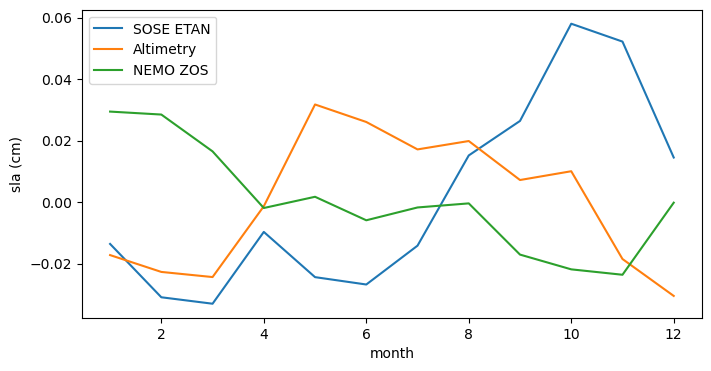

In [23]:
# compare climatologies
fig,ax = plt.subplots(figsize=(8,4))
soseclim=etanav.sel(time=slice(t1,t2)).groupby('time.month').mean()
alticlim=slaav.sel(time=slice(t1,t2)).groupby('time.month').mean()
nemoclim=zosav.sel(time_counter=slice(t1,t2)).groupby('time_counter.month').mean()

ax.plot(soseclim.month,soseclim,label='SOSE ETAN')
ax.plot(alticlim.month,alticlim,label='Altimetry')
ax.plot(nemoclim.month,nemoclim,label='NEMO ZOS')

ax.legend()
ax.set_xlabel('month')
ax.set_ylabel('sla (cm)')


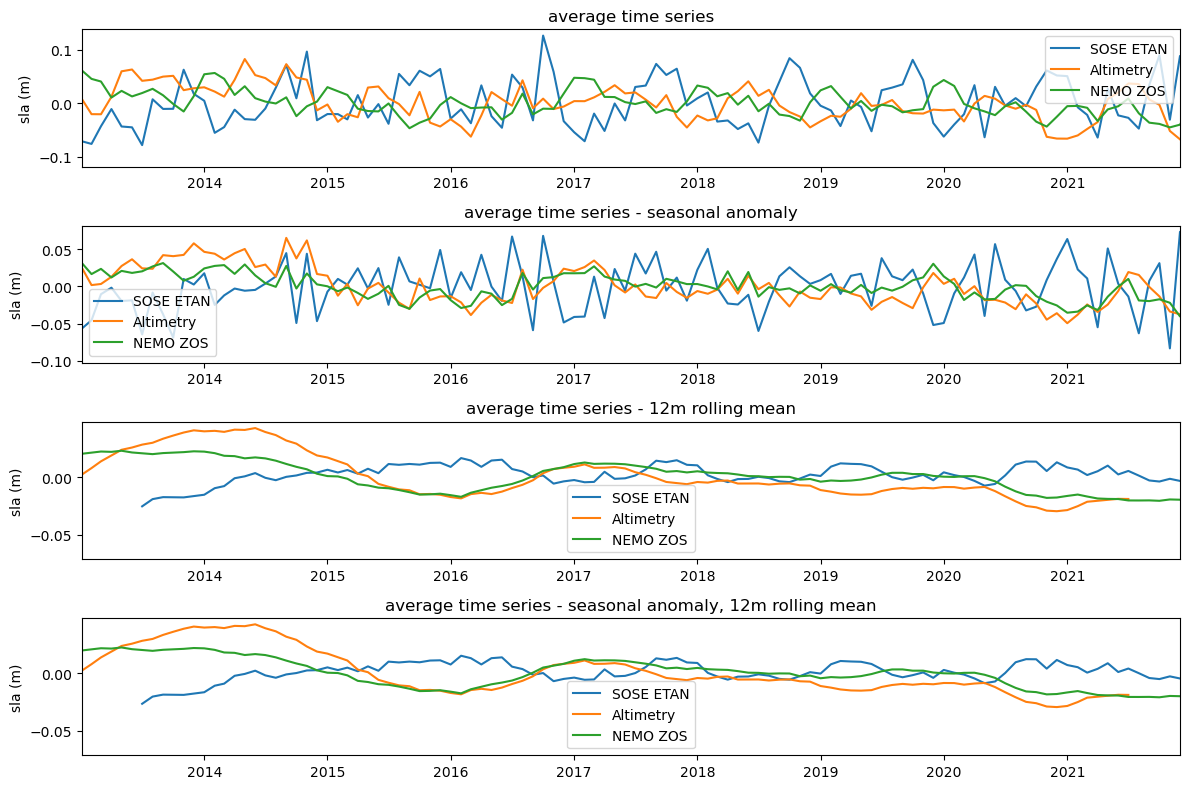

In [25]:
# compare time series
fig,axs = plt.subplots(4,1,figsize=(12,8))

# 1 - straightforward timeseries
ax=axs[0]
ax.plot(etan.time,etanav,label='SOSE ETAN')
ax.plot(sla.time,slaav,label='Altimetry')
ax.plot(zos.time_counter,zosav,label='NEMO ZOS')
ax.set_title('average time series')

ax.legend()
ax.set_ylabel('sla (m)')
ax.set_xlim([t1,t2])


# 2 - seasonal anomaly
ax=axs[1]
ax.plot(etan.time,etanav.groupby('time.month') - soseclim,label='SOSE ETAN')
ax.plot(sla.time,slaav.groupby('time.month') - alticlim,label='Altimetry')
ax.plot(zos.time_counter,zosav.groupby('time_counter.month') - nemoclim,label='NEMO ZOS')
ax.set_title('average time series - seasonal anomaly')

ax.legend()
ax.set_ylabel('sla (m)')
ax.set_xlim([t1,t2])


# 3 - rolling timeseries
ax=axs[2]
ax.plot(etan.time,etanav.rolling({'time':12},center=True).mean(),label='SOSE ETAN')
ax.plot(sla.time,slaav.rolling({'time':12},center=True).mean(),label='Altimetry')
ax.plot(zos.time_counter,zosav.rolling({'time_counter':12},center=True).mean(),label='NEMO ZOS')
ax.set_title('average time series - 12m rolling mean')

ax.legend()
ax.set_ylabel('sla (m)')
ax.set_xlim([t1,t2])


# 4 - rolling timeseries
ax=axs[3]
ax.plot(etan.time,(etanav.groupby('time.month') - soseclim).rolling({'time':12},center=True).mean(),label='SOSE ETAN')
ax.plot(sla.time,(slaav.groupby('time.month') - alticlim).rolling({'time':12},center=True).mean(),label='Altimetry')
ax.plot(zos.time_counter,(zosav.groupby('time_counter.month') - nemoclim).rolling({'time_counter':12},center=True).mean(),label='NEMO ZOS')
ax.set_title('average time series - seasonal anomaly, 12m rolling mean')

ax.legend()
ax.set_ylabel('sla (m)')
ax.set_xlim([t1,t2])


plt.tight_layout()